Impoting dataset

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/content/Bank Customer Churn Prediction.csv')

In [5]:
df.sample(5)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
2765,15733876,667,France,Male,36,9,0.00,2,1,1,40062.29,0
5033,15690743,536,France,Female,61,8,65190.29,1,1,1,64308.49,1
1639,15723053,504,Germany,Male,32,8,170291.22,2,0,1,15658.99,0
7841,15789563,706,Germany,Female,46,7,111288.18,1,1,1,149170.25,1
1234,15684865,771,France,Female,66,7,143773.07,1,1,1,130827.88,0


Checking basic info

In [6]:
df.shape

(10000, 12)

In [7]:
df.columns.tolist()

['customer_id',
 'credit_score',
 'country',
 'gender',
 'age',
 'tenure',
 'balance',
 'products_number',
 'credit_card',
 'active_member',
 'estimated_salary',
 'churn']

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [9]:
df.isnull().sum()

,0
customer_id,0
credit_score,0
country,0
gender,0
age,0
tenure,0
balance,0
products_number,0
credit_card,0
active_member,0


In [10]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [11]:
df.duplicated().sum()

np.int64(0)

Understanding `Target Variable`

Churn value counts: 
 churn
0    7963
1    2037
Name: count, dtype: int64


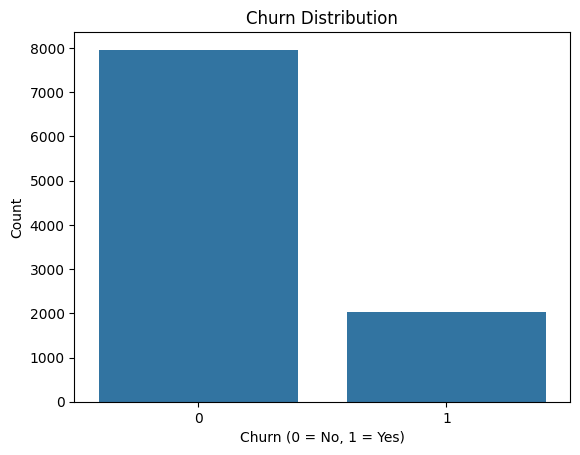

In [12]:
# Count of churned vs non-churned
df['churn'].value_counts()
print("Churn value counts: \n", df['churn'].value_counts())

# Plot churn distribution
sns.countplot(x='churn', data=df)
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

Handling `Categorical Variable`

#####Encoding Gender

In [13]:
df['gender'].value_counts()

,count
gender,
Male,5457
Female,4543


In [14]:
df['gender'] = df['gender'].replace({'Male': 1, 'Female': 0})

/tmp/ipykernel_591/3014946458.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'] = df['gender'].replace({'Male': 1, 'Female': 0})


In [15]:
df['gender']

,gender
0,0
1,0
2,0
3,0
4,0
...,...
9995,1
9996,1
9997,0
9998,1


#####One Hot Encoding in Nominal Categorical Variable: Countery

In [16]:
df['country'].value_counts()

,count
country,
France,5014
Germany,2509
Spain,2477


In [17]:
df = pd.get_dummies(df, columns=['country'], drop_first=True)
# using k-1 OHE to avoid dummy variable trap

Check and Handle Class Imbalance

In [18]:
df['churn']

,churn
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


In [19]:
# Normalizing the Target Variable to see the imbalance.
df['churn'].value_counts(normalize=True)

,proportion
churn,
0,0.7963
1,0.2037


In [20]:
print("The dataset is imbalanced." if df['churn'].value_counts(normalize=True).min() < 0.4 else "The dataset is balanced.")

The dataset is imbalanced.


Scaling Numerical Features

`Train-Test-Split`

In [21]:
# Separate Feature and Target

X = df.drop('churn', axis=1)
y = df['churn']

In [22]:
X.sample(5)

,customer_id,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,country_Germany,country_Spain
1060,15650933,490,0,48,8,155413.06,1,1,0,187921.30,False,True
635,15633648,696,0,51,5,0.00,2,1,0,55022.43,False,True
3864,15808960,620,1,40,5,108197.11,2,1,0,49722.34,True,False
2961,15583681,616,1,31,7,76665.71,2,1,1,163809.08,False,True
9754,15572114,673,1,40,1,121629.22,1,1,1,3258.60,False,True


In [23]:
y.sample(5)

,churn
5501,0
1520,1
4724,0
6062,0
8701,0


In [24]:
# train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [25]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8000, 12), (2000, 12), (8000,), (2000,))

In [26]:
# Applying StandardScaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
X_test_scaled
X_train_scaled

array([[-1.42167772,  1.058568  ,  0.90750738, ...,  1.04208392,
        -0.57831252, -0.57773517],
       [-0.69120691,  0.91362605,  0.90750738, ..., -0.62355635,
         1.72916886, -0.57773517],
       [ 0.82211776,  1.07927399, -1.10191942, ...,  0.30812779,
         1.72916886, -0.57773517],
       ...,
       [ 0.26278153,  0.16821031, -1.10191942, ..., -0.55808767,
        -0.57831252, -0.57773517],
       [-0.02019528,  0.37527024,  0.90750738, ..., -1.35149956,
        -0.57831252,  1.73089688],
       [ 1.18510103,  1.56586482,  0.90750738, ..., -1.02692216,
        -0.57831252,  1.73089688]])

##EDA

Distribution of Target Variable

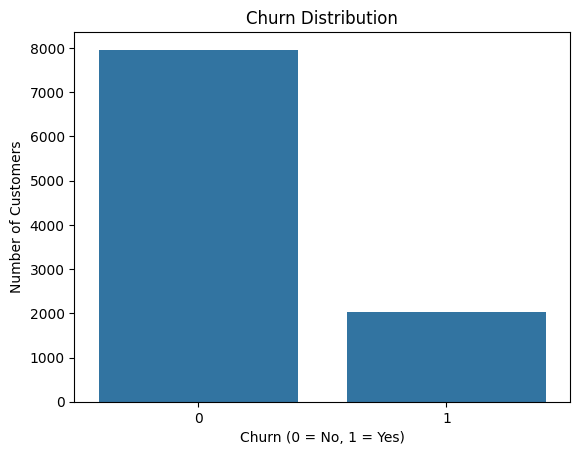

This count plot compares the number of customers who stayed (churn = 0) and left the bank (churn = 1) across genders


In [28]:
sns.countplot(x='churn', data=df)
plt.title('Churn Distribution')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.show()

print("This count plot compares the number of customers who stayed (churn = 0) and left the bank (churn = 1) across genders")

Churn Rate by Gender

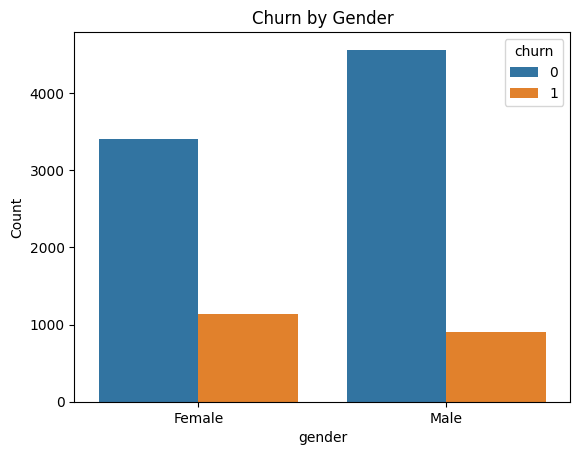

In [29]:
sns.countplot(x='gender', hue='churn', data=df)
plt.title('Churn by Gender')
plt.xticks([0,1], ['Female', 'Male'])
plt.ylabel('Count')
plt.show()

* *Female customers have a higher tendency to churn.*

Churn Rate by Country

In [30]:
df1 = df.copy()

In [31]:
df1['Country'] = 'France'

df1.loc[df1['country_Germany'] == 1, 'Country'] = 'Germany'
df1.loc[df1['country_Spain'] == 1, 'Country'] = 'Spain'

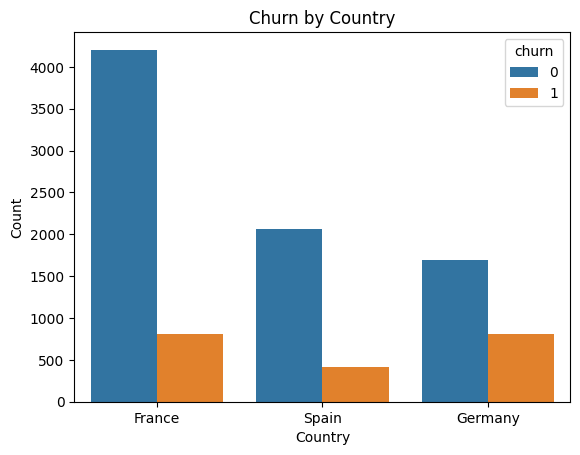

In [32]:
sns.countplot(x='Country', hue='churn', data=df1)

plt.title('Churn by Country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.show()

*  *Germany exhibits the highest customer churn rate despite having fewer customers, while Spain has the lowest churn rate and France has the largest customer base with a moderate level of churn.*




Boxplot for Numerical Features

1. Age vs Churn

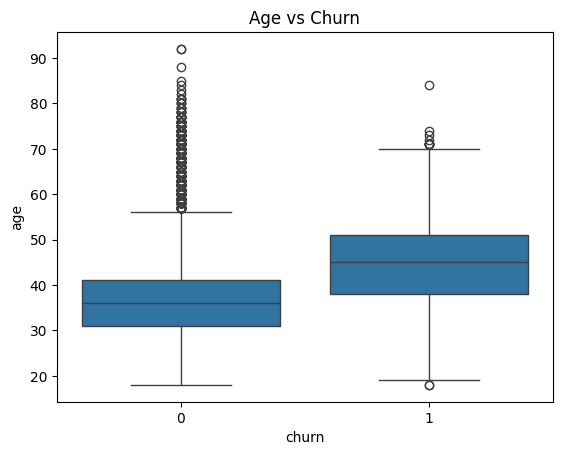

In [33]:
sns.boxplot(x='churn', y='age', data=df)
plt.title('Age vs Churn')
plt.show()

* *Churned customers are generally older than retained customers, implying that older customers are more likely to leave the bank.*

2. Balance vs Churn

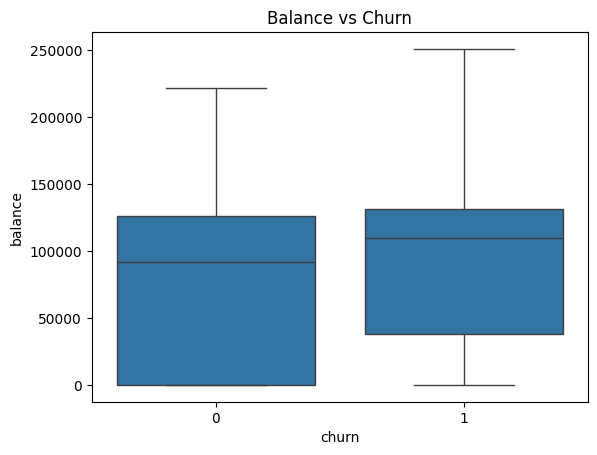

In [34]:
sns.boxplot(x='churn', y='balance', data=df)
plt.title('Balance vs Churn')
plt.show()

* *Customers with larger balances may be more likely to leave the bank.*

3. Credit Score vs Churn

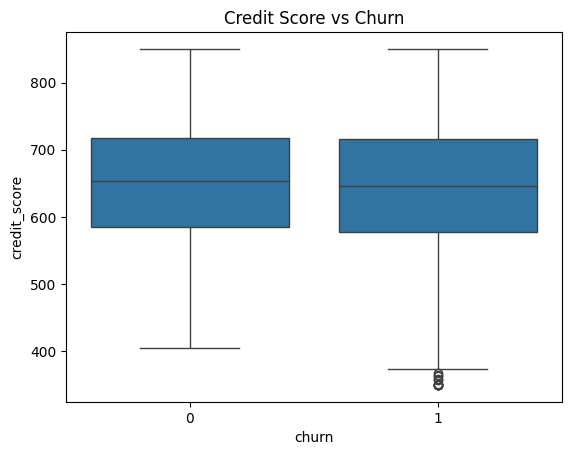

In [35]:
sns.boxplot(x='churn', y='credit_score', data=df)
plt.title('Credit Score vs Churn')
plt.show()

* *Credit Score has little influence on churn*

Countplot for Binary Features

1. Credit Card Ownership vs Churn

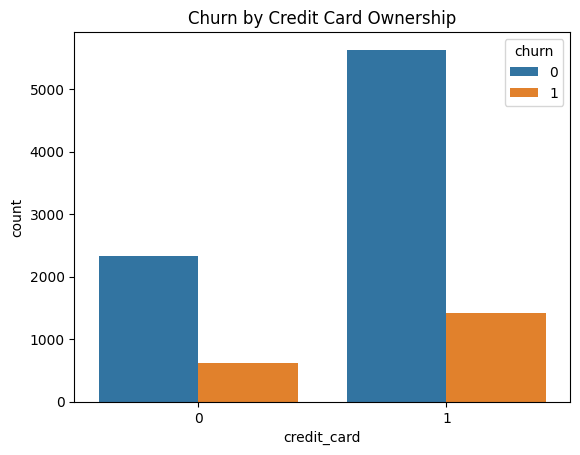

In [36]:
sns.countplot(x='credit_card', hue='churn', data=df)
plt.title('Churn by Credit Card Ownership')
plt.show()

In [37]:
pd.crosstab(df['credit_card'], df['churn'], normalize='index') * 100

churn,0,1
credit_card,,
0,79.185059,20.814941
1,79.815734,20.184266


* *Customers with and without a credit card exhibit nearly identical churn rates (20.18% vs. 20.81%), indicating that credit card ownership has weak influence on customer churn.*

2. Active Member vs Churn

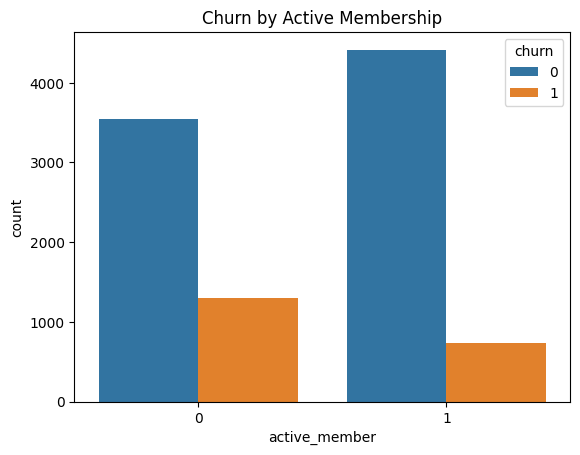

In [38]:
sns.countplot(x='active_member', hue='churn', data=df)
plt.title('Churn by Active Membership')
plt.show()

In [39]:
pd.crosstab(df['active_member'], df['churn'], normalize='index') * 100

churn,0,1
active_member,,
0,73.149103,26.850897
1,85.730926,14.269074


* *Inactive customers are nearly twice as likely to churn as active customers (26.85% vs. 14.27%).*

*{Active Member → whether the customer regularly uses the bank's services.*

*Churn → whether the customer eventually leaves the bank.}*

Correlation HeatMap

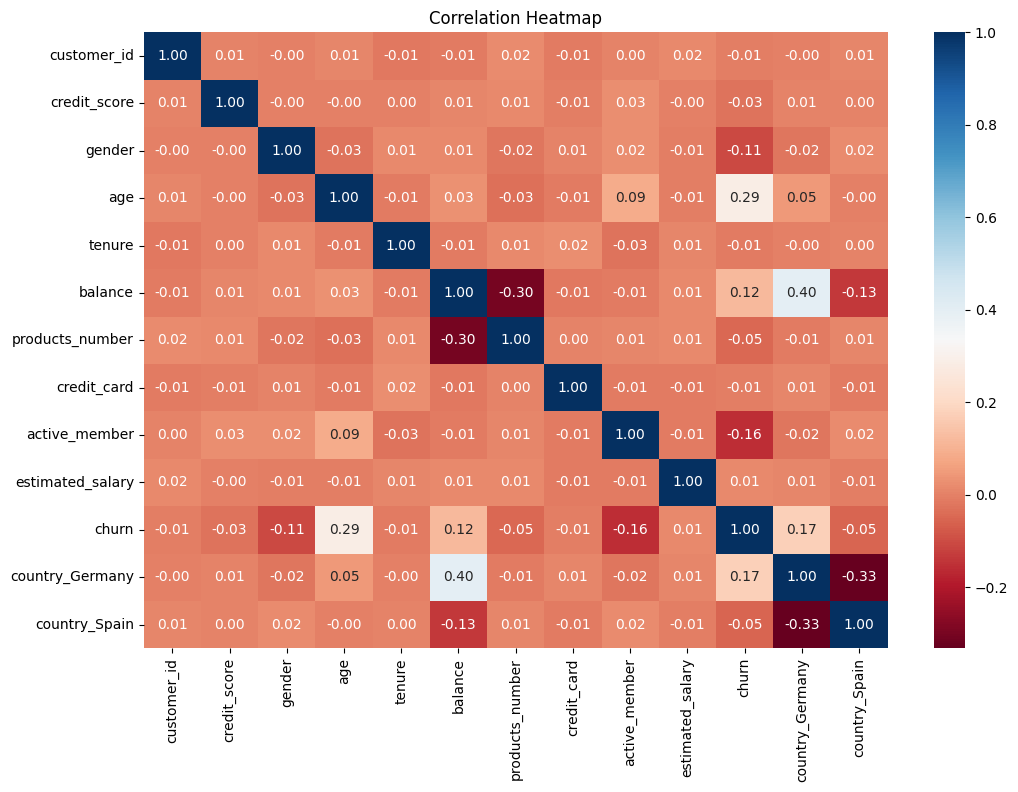

In [40]:
plt.figure(figsize=(12,8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu')
plt.title('Correlation Heatmap')
plt.show()

In [41]:
df.corr()['churn']

,churn
customer_id,-0.006248
credit_score,-0.027094
gender,-0.106512
age,0.285323
tenure,-0.014001
balance,0.118533
products_number,-0.047820
credit_card,-0.007138
active_member,-0.156128
estimated_salary,0.012097


* *Age, active membership, balance, and geographic location (Germany) are the most influential factors associated with customer churn.*

##
Build and Train Machine Learning Models

In [42]:
X_train_scaled, X_test_scaled, y_train, y_test

(array([[-1.42167772,  1.058568  ,  0.90750738, ...,  1.04208392,
         -0.57831252, -0.57773517],
        [-0.69120691,  0.91362605,  0.90750738, ..., -0.62355635,
          1.72916886, -0.57773517],
        [ 0.82211776,  1.07927399, -1.10191942, ...,  0.30812779,
          1.72916886, -0.57773517],
        ...,
        [ 0.26278153,  0.16821031, -1.10191942, ..., -0.55808767,
         -0.57831252, -0.57773517],
        [-0.02019528,  0.37527024,  0.90750738, ..., -1.35149956,
         -0.57831252,  1.73089688],
        [ 1.18510103,  1.56586482,  0.90750738, ..., -1.02692216,
         -0.57831252,  1.73089688]]),
 array([[ 0.81552817, -0.68073539,  0.90750738, ..., -0.09502138,
         -0.57831252, -0.57773517],
        [ 1.61906831, -1.30191518,  0.90750738, ..., -0.778941  ,
          1.72916886, -0.57773517],
        [ 1.53179106, -0.97061929, -1.10191942, ...,  0.09946914,
         -0.57831252,  1.73089688],
        ...,
        [ 0.46493165, -1.39509214, -1.10191942, ...,  

*Logistic Regression*

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# imnbalanced dataset so we take roc, auc score

In [44]:
# Create model
lr = LogisticRegression()

# Train model
lr.fit(X_train_scaled, y_train)

# Binary predictions
y_pred_lr_binary = lr.predict(X_test_scaled)

# Probabilities
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

# Classification report : we need binary
print(classification_report(y_test, y_pred_lr_binary))

# ROC-AUC : we need probabilities
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.29       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000

ROC-AUC: 0.7745264524925541


roc_auc_score was designed to evaluate ranking/probabilities, not final binary decisions.

We are only the probability of Class 1 (Churn).

In [45]:
from sklearn.model_selection import cross_val_score

# Cross-validation ROC-AUC
cv_roc_auc = cross_val_score(
    LogisticRegression(max_iter=1000),
    X_train_scaled,
    y_train,
    cv=5,
    scoring='roc_auc'
)

print("Cross-Validation ROC-AUC Scores:", cv_roc_auc)
print("Mean ROC-AUC:", cv_roc_auc.mean())
print("Standard Deviation:", cv_roc_auc.std())

Cross-Validation ROC-AUC Scores: [0.76996514 0.76180043 0.75783966 0.78093007 0.74588755]
Mean ROC-AUC: 0.7632845681925436
Standard Deviation: 0.011751592822145567


*Random Forest*

In [46]:
X_train

,customer_id,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,country_Germany,country_Spain
2151,15588614,753,1,57,7,0.00,1,1,0,159475.08,False,False
8392,15641158,739,1,32,3,102128.27,1,1,0,63981.37,True,False
5006,15750014,755,0,37,0,113865.23,2,1,1,117396.25,True,False
4117,15663964,561,1,37,5,0.00,2,1,0,83093.25,False,False
7182,15573520,692,1,49,6,110540.43,2,0,1,107472.99,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
4555,15733261,688,0,35,6,0.00,1,1,0,25488.43,False,True
4644,15714240,712,1,74,5,0.00,2,0,0,151425.82,False,True
8942,15709780,667,0,37,9,71786.90,2,1,1,67734.79,False,False
2935,15689425,687,1,35,8,100988.39,2,1,0,22247.27,False,True


In [47]:
X_test_scaled

array([[ 0.81552817, -0.68073539,  0.90750738, ..., -0.09502138,
        -0.57831252, -0.57773517],
       [ 1.61906831, -1.30191518,  0.90750738, ..., -0.778941  ,
         1.72916886, -0.57773517],
       [ 1.53179106, -0.97061929, -1.10191942, ...,  0.09946914,
        -0.57831252,  1.73089688],
       ...,
       [ 0.46493165, -1.39509214, -1.10191942, ...,  0.8700859 ,
         1.72916886, -0.57773517],
       [-0.08019665,  0.39597623,  0.90750738, ..., -1.47935555,
        -0.57831252, -0.57773517],
       [-0.53744992,  1.02750901,  0.90750738, ..., -0.49531855,
        -0.57831252, -0.57773517]])

In [48]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf = RandomForestClassifier(random_state=42)

# Train model
rf.fit(X_train, y_train)

# Binary predictions
y_pred_rf = rf.predict(X_test)

# Probabilities
y_prob_rf = rf.predict_proba(X_test)[:,1]

# Classification report
print("Random Forest:\n")
print(classification_report(y_test, y_pred_rf))

# ROC-AUC
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Random Forest:

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.46      0.58       407

    accuracy                           0.87      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000

ROC-AUC: 0.8506742489793337


In [49]:
cv_rf = cross_val_score(
    RandomForestClassifier(random_state=42),
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc'
)

print("Cross-Validation ROC-AUC Scores:", cv_rf)
print("Mean ROC-AUC:", cv_rf.mean())
print("Std Dev:", cv_rf.std())

Cross-Validation ROC-AUC Scores: [0.85549715 0.85714526 0.83765205 0.85807105 0.86808371]
Mean ROC-AUC: 0.8552898459997497
Std Dev: 0.009858960613994664


*XGBoost*

In [50]:
from xgboost import XGBClassifier

# Create model
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Train model
xgb.fit(X_train, y_train)

# Binary predictions
y_pred_xgb = xgb.predict(X_test)

# Probabilities
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

# Classification Report
print("XGBoost:\n")
print(classification_report(y_test, y_pred_xgb))

# ROC-AUC
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:09:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost:

              precision    recall  f1-score   support

           0       0.87      0.95      0.91      1593
           1       0.69      0.47      0.56       407

    accuracy                           0.85      2000
   macro avg       0.78      0.71      0.73      2000
weighted avg       0.84      0.85      0.84      2000

ROC-AUC: 0.8288504220707611


In [51]:
cv_xgb = cross_val_score(
    XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    ),
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc'
)

print("Cross-Validation ROC-AUC Scores:", cv_xgb)
print("Mean ROC-AUC:", cv_xgb.mean())
print("Std Dev:", cv_xgb.std())

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:09:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:09:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:09:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:09:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Cross-Validation ROC-AUC Scores: [0.83394651 0.85268369 0.83204679 0.85414761 0.85679373]
Mean ROC-AUC: 0.8459236644162148
Std Dev: 0.010653726575749005


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:09:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Comparision

In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []

# Logistic Regression
results.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred_lr_binary),
    'Precision': precision_score(y_test, y_pred_lr_binary),
    'Recall': recall_score(y_test, y_pred_lr_binary),
    'F1 Score': f1_score(y_test, y_pred_lr_binary),
    'ROC-AUC': roc_auc_score(y_test, y_prob_lr),
    'CV ROC-AUC': cv_roc_auc.mean()
})

# Random Forest
results.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1 Score': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_prob_rf),
    'CV ROC-AUC': cv_roc_auc.mean()
})

# XGBoost
results.append({
    'Model': 'XGBoost',
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb),
    'F1 Score': f1_score(y_test, y_pred_xgb),
    'ROC-AUC': roc_auc_score(y_test, y_prob_xgb),
    'CV ROC-AUC': cv_xgb.mean()
})

results_df = pd.DataFrame(results)

# Round to 3 decimal places
results_df = results_df.round(3)

print(results_df)

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC  \
0  Logistic Regression     0.808      0.592   0.189     0.287    0.775   
1        Random Forest     0.866      0.792   0.459     0.582    0.851   
2              XGBoost     0.848      0.687   0.469     0.558    0.829   

   CV ROC-AUC  
0       0.763  
1       0.763  
2       0.846  


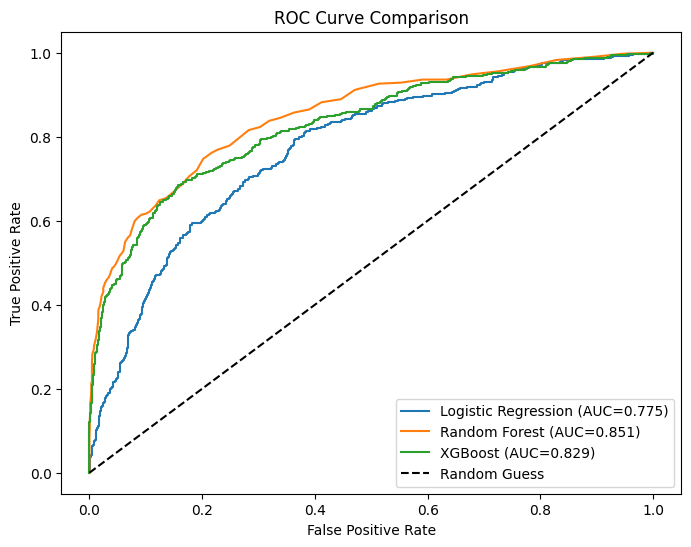

In [53]:
from sklearn.metrics import roc_curve, roc_auc_score

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr,
         label=f'Logistic Regression (AUC={roc_auc_score(y_test,y_prob_lr):.3f})')

plt.plot(fpr_rf, tpr_rf,
         label=f'Random Forest (AUC={roc_auc_score(y_test,y_prob_rf):.3f})')

plt.plot(fpr_xgb, tpr_xgb,
         label=f'XGBoost (AUC={roc_auc_score(y_test,y_prob_xgb):.3f})')

plt.plot([0,1],[0,1],'k--',label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

For ROC analysis, the best model is the one whose curve stays closest to the upper-left corner, which means:

* Higher True Positive Rate (detects
more churners)
* Lower False Positive Rate (fewer false alarms)

**Among the three models evaluated, *Random Forest* demonstrated the best overall performance.**

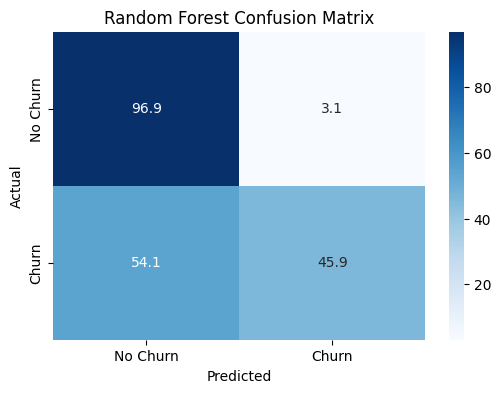

True Negatives: 1544
False Positives: 49
False Negatives: 220
True Positives: 187


In [54]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_percent,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()


tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

* *The model correctly identifies 96.9% of non-churn customers but only 45.9% of churn customers.*

### Why are customers churning?

             Feature  Importance
3                age    0.221450
6    products_number    0.126237
9   estimated_salary    0.120171
5            balance    0.119400
1       credit_score    0.116351
4             tenure    0.067850
8      active_member    0.037103
10   country_Germany    0.028777
7        credit_card    0.016593
2             gender    0.016476


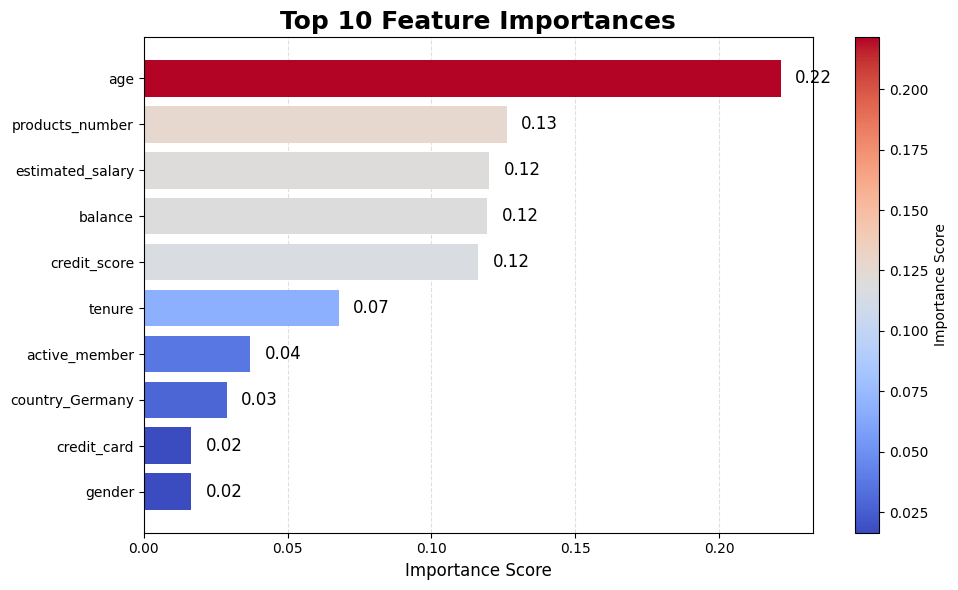

In [55]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})
# Remove customer_id from the plot
feature_importance = feature_importance[
    feature_importance['Feature'] != 'customer_id'
]
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

# Example top 10 features
top10 = feature_importance.head(10)

# Normalize importance values
norm = mcolors.Normalize(
    vmin=top10['Importance'].min(),
    vmax=top10['Importance'].max()
)

# Red (high importance) -> Blue (low importance)
cmap = cm.coolwarm
colors = cmap(norm(top10['Importance']))

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Horizontal bars
bars = ax.barh(
    top10['Feature'],
    top10['Importance'],
    color=colors
)

# Value labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.005,
        bar.get_y() + bar.get_height()/2,
        f'{width:.2f}',
        va='center',
        fontsize=12
    )

# Formatting
ax.set_title('Top 10 Feature Importances',
             fontsize=18,
             fontweight='bold')

ax.set_xlabel('Importance Score', fontsize=12)

ax.invert_yaxis()  # Highest importance on top

# Add gridlines
ax.grid(axis='x',
        linestyle='--',
        alpha=0.4)

ax.set_axisbelow(True)

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Importance Score', fontsize=10)

plt.tight_layout()
plt.show()

*Feature importance analysis indicates that **Age** is the most significant factor influencing customer churn, followed by the number of products held, estimated salary, account balance, and credit score.*